# Linear Regression with Weather Data #

-In this study, a weather dataset is examined, data cleaning and preprocessing operations are performed, correlations between variables are analyzed, and a Linear Regression model is created to predict the Temperature (C) variable.

# 1 . Importing the Required Libraries
   
-pandas: Used to read the dataset and perform DataFrame operations.

-numpy: Used for numerical operations.

-matplotlib.pyplot: Used to create visualizations. 

-seaborn: Used to create statistical visualizations. 

-%matplotlib inline allows the graphs to be displayed directly inside the Jupyter Notebook. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline 

# 2 . Reading the Dataset

The weatherHistory.csv file is read using the pd.read_csv() function and assigned to a DataFrame named df.

In [2]:
df = pd.read_csv("weatherHistory.csv") 

# 3 . Examining the First Rows of the Dataset

df.head() displays the first five rows of the dataset by default.

This allows us to quickly examine:

-Column names

-Data structure

-Example values

In [4]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


# 4 . Examining General Information About the Dataset

df.info() provides general information about the dataset, including:

-Number of rows and columns

-Column names

-Data types of the columns

-Number of non-null values in each column

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


# 5 . Statistical Summary of Numerical Variables

df.describe() provides basic statistical information about the numerical columns.

It includes:

-Number of observations (count)

-Mean value (mean)

-Standard deviation (std)

-Minimum and maximum values

-Quartile values (25%, 50%, and 75%)


In [6]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


# 6 . Checking Missing Values

df.isnull().sum() shows the total number of missing values in each column.

This step helps determine which columns require data cleaning operations.

In [7]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

# 7 . Checking Duplicate Rows

df.duplicated().sum() returns the total number of completely duplicated rows in the dataset.

In [9]:
df.duplicated().sum()

np.int64(24)

# 8 . Creating a Copy of the Original Dataset

A separate copy of the original DataFrame is created using df.copy() and assigned to df_new.

Data cleaning and preprocessing operations are performed on this copy so that the original DataFrame remains unchanged.

In [8]:
df_new = df.copy()

In [11]:
df_new.shape

(96453, 12)

# 9 . Removing Duplicate Rows

drop_duplicates() removes duplicated rows from the dataset.

inplace=True applies the operation directly to df_new.

Therefore, a new DataFrame does not need to be created.

In [12]:
df_new.drop_duplicates(inplace=True)

In [14]:
df_new.shape

(96429, 12)

# 10 . Removing an Unnecessary Column

The Loud Cover column is removed from the dataset using the drop() method because it will not be used in the model.

columns="Loud Cover" specifies the column to be removed.

inplace=True applies the change directly to df_new.

In [19]:
df_new.drop(columns="Loud Cover",inplace=True)

In [20]:
df_new.shape

(96429, 11)

# 11 . Removing Missing Precipitation Type Values

Rows containing missing values in the Precip Type column are removed using dropna().

The subset=["Precip Type"] parameter ensures that missing values are checked only in the Precip Type column.

In [22]:
df_new.dropna(subset=["Precip Type"], inplace=True)


In [23]:
df_new.shape

(95912, 11)

# 12 . Converting a Categorical Variable into Numerical Values

Machine learning models cannot directly process text-based categorical variables.

Therefore, One-Hot Encoding is applied to the Precip Type column.

pd.get_dummies() converts categories into new numerical columns.
    
drop_first=True removes the first category to avoid redundant information.
    
dtype=int ensures that the generated values are integers represented as 0 and 1.

In [42]:
df_new = pd.get_dummies(df_new, columns= ["Precip Type"],drop_first=True,dtype=int)

# 13 . Selecting Numerical Columns

select_dtypes(include=["float64"]) selects the columns whose data type is float64.

The selected column names are converted into a list using list() and stored in the numeric_columns variable.

In [43]:
numeric_columns = list(df_new.select_dtypes(include=["float64"]))

In [44]:
numeric_columns

['Temperature (C)',
 'Apparent Temperature (C)',
 'Humidity',
 'Wind Speed (km/h)',
 'Wind Bearing (degrees)',
 'Visibility (km)',
 'Pressure (millibars)']

# 14 . Calculating the Correlation Matrix

The corr() method calculates the direction and strength of the linear relationship between numerical variables.

The correlation coefficient can be interpreted as follows:

-A value close to 1 indicates a strong positive relationship.

-A value close to -1 indicates a strong negative relationship.

-A value close to 0 indicates a weak linear relationship.

In [45]:
correlation = df_new[numeric_columns].corr()

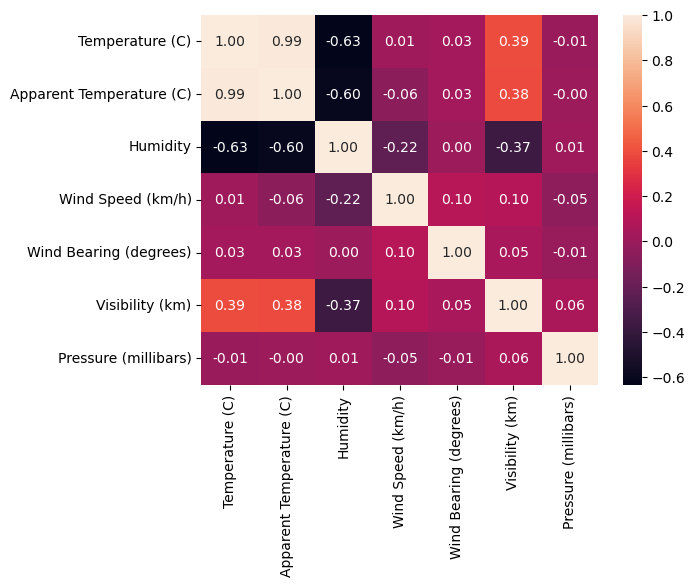

In [46]:
sns.heatmap(correlation,annot=True,fmt=".2f")
plt.show()

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
from sklearn.model_selection import train_test_split 

In [49]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_percentage_error,mean_squared_error

In [50]:
regression = LinearRegression()

In [51]:
df_new.columns

Index(['Formatted Date', 'Summary', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)',
       'Daily Summary', 'Precip Type_snow'],
      dtype='object')

# 15 . Splitting the Dataset into Training and Test Sets

The dataset is divided into training and test sets.

test_size=0.25 means that 25% of the dataset is used for testing and 75% is used for training.

random_state=42 ensures that the same train-test split is produced every time the code is executed.

The generated variables are:

X_train and y_train: Used to train the model.

X_test and y_test: Used to evaluate the model.

In [52]:
X= df_new[['Apparent Temperature (C)','Humidity','Wind Speed (km/h)','Wind Bearing (degrees)','Visibility (km)','Pressure (millibars)','Precip Type_snow']]
y= df_new["Temperature (C)"]

In [54]:
X_train,X_test,y_train, y_test= train_test_split(X,y,test_size=0.25,random_state=42)

# 16. Training the Model

The fit() method trains the Linear Regression model using the training data.

The model learns the linear relationship between the independent variables and the temperature variable.

In [55]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
y_pred = regression.predict(X_test)

# 17 . Evaluating the Model Performance

The actual test values, y_test, are compared with the predicted values, y_pred.

The following evaluation metrics are calculated:

-MAE: Shows the average absolute prediction error. A lower value is preferred.

-MAPE: Shows the average percentage error. A lower value is preferred.

-MSE: Calculates the average squared prediction error and penalizes large errors more heavily. A lower value is preferred.

-R² Score: Shows how much of the variation in the target variable is explained by the model. A value closer to 1 generally indicates a better model fit.

In [57]:
print("MAE : ",mean_absolute_error(y_test,y_pred))
print("MAPE : ",mean_absolute_percentage_error(y_test,y_pred))
print("MSE : ",mean_squared_error(y_test,y_pred))
print("R2 score : ",r2_score(y_test,y_pred))

MAE :  0.7432163585434002
MAPE :  18458882346758.105
MSE :  0.9042182462265484
R2 score :  0.9901700017289466


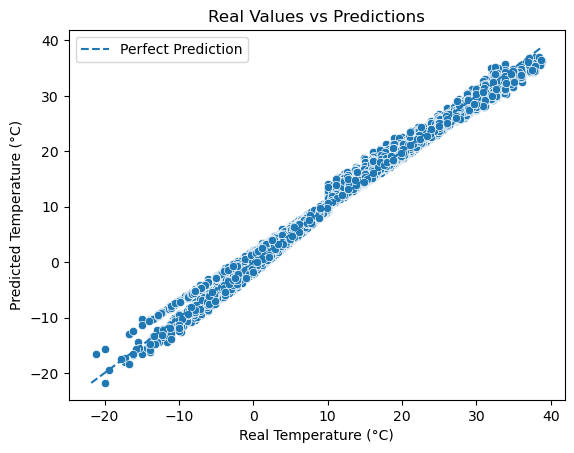

In [62]:
plot_df = pd.DataFrame({
    "Real_Values": np.asarray(y_test).ravel(),
    "Predictions": np.asarray(y_pred).ravel()
})

sns.scatterplot(
    data=plot_df,
    x="Real_Values",
    y="Predictions"
)


minimum = min(plot_df["Real_Values"].min(),
              plot_df["Predictions"].min())

maximum = max(plot_df["Real_Values"].max(),
              plot_df["Predictions"].max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Real Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Real Values vs Predictions")
plt.legend()
plt.show()

# CONCLUSION
In this study, the weather data was cleaned and used to train a Linear Regression model. The model achieved an R² score of 0.99 and a low average prediction error. These results show that the model can predict temperature accurately.